# Deep Neural Networks

In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
a = tf.constant([1,2,3,4], shape = [2,2])
b = tf.constant([5,6,7,8], shape  = [2,2])

print(f"tensor a: {a}", f"tensor b:{b}")
print("*"*50)
print(f"a+b:{tf.add(a,b)}")
print("*"*50)
print(f"a*b:{tf.multiply(a,b)}")
print("*"*50)
print(f"a.b:{tf.matmul(a,b)}")

tensor a: [[1 2]
 [3 4]] tensor b:[[5 6]
 [7 8]]
**************************************************
a+b:[[ 6  8]
 [10 12]]
**************************************************
a*b:[[ 5 12]
 [21 32]]
**************************************************
a.b:[[19 22]
 [43 50]]


# Simple model


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [22]),
    tf.keras.layers.Dense(units = 64, activation = tf.nn.sigmoid, name = 'layer_1'),
    tf.keras.layers.Dense(units = 182, activation = tf.nn.relu, name = 'layer_2'),
    tf.keras.layers.Dense(units = 1, activation = tf.nn.sigmoid, name = 'layer_3')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 182)            │        11,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_3 (Dense)                 │ (None, 1)              │           183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,485 (52.68 KB)

 Trainable params: 13,485 (52.68 KB)

 Non-trainable params: 0 (0.00 B)

# Sequential

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

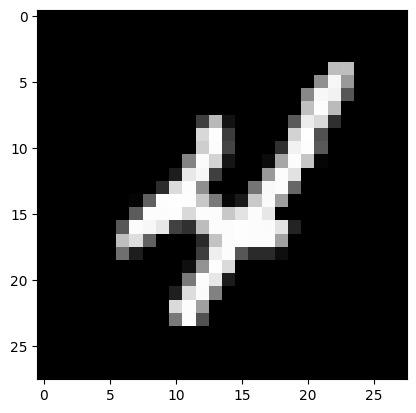

In [ ]:
plt.imshow(x_train[9], cmap = 'gray')

In [ ]:
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Normalization:
# 255: The max number of pixels to create a color. [0,1]
#0: none, 255: saturated (number of pixels in one byte)
x_train, x_test = x_train/255, x_test/255


In [ ]:
y_train, y_test = (tf.one_hot(y_train, 10)), (tf.one_hot(y_test, 10))


In [ ]:
x_train.shape

(60000, 784)

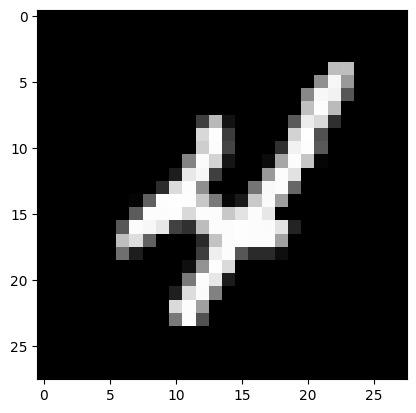

In [ ]:
plt.imshow(x_train[9].reshape(28,28), cmap = 'gray')

In [ ]:
# The easiest way to build a model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [784]),
    tf.keras.layers.Dense(units = 128, activation = tf.nn.sigmoid),
    tf.keras.layers.Dense(units = 256, activation = tf.nn.relu),
    tf.keras.layers.Dense(units = 512, activation = tf.nn.relu),
    tf.keras.layers.Dense(units = 10, activation = tf.nn.sigmoid)
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,218 (1.03 MB)

 Trainable params: 270,218 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss =tf.losses.CategoricalCrossentropy,
              metrics = [tf.metrics.CategoricalAccuracy])

In [ ]:
model.fit(x = x_train, y = y_train, batch_size = 32, epochs = 10, validation_split = 0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - categorical_accuracy: 0.8070 - loss: 0.5943 - val_categorical_accuracy: 0.9578 - val_loss: 0.1350
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - categorical_accuracy: 0.9493 - loss: 0.1612 - val_categorical_accuracy: 0.9657 - val_loss: 0.1089
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - categorical_accuracy: 0.9675 - loss: 0.1059 - val_categorical_accuracy: 0.9733 - val_loss: 0.0856
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - categorical_accuracy: 0.9762 - loss: 0.0771 - val_categorical_accuracy: 0.9723 - val_loss: 0.0967
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - categorical_accuracy: 0.9809 - loss: 0.0584 - val_categorical_accuracy: 0.9783 - val_loss: 0.0831
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - categorical_accuracy: 0.9846 - loss: 0.0458 - val_categorical_accuracy: 0.9747 - val_loss: 0.0914
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - categorical

# Functional API

In [ ]:
input_layer = tf.keras.layers.Input(shape = [784])
dense_layer_1 = tf.keras.layers.Dense(units = 128, activation = tf.nn.sigmoid)(input_layer)
dense_layer_2 = tf.keras.layers.Dense(units = 512, activation = tf.nn.relu)(dense_layer_1)
dense_layer_3 = tf.keras.layers.Dense(units = 256, activation = tf.nn.relu)(dense_layer_2)
output_layer = tf.keras.layers.Dense(units = 10, activation = tf.nn.sigmoid)(dense_layer_3)

model = tf.keras.Model(inputs = [input_layer], outputs = [output_layer])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,426 (1.15 MB)

 Trainable params: 300,426 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

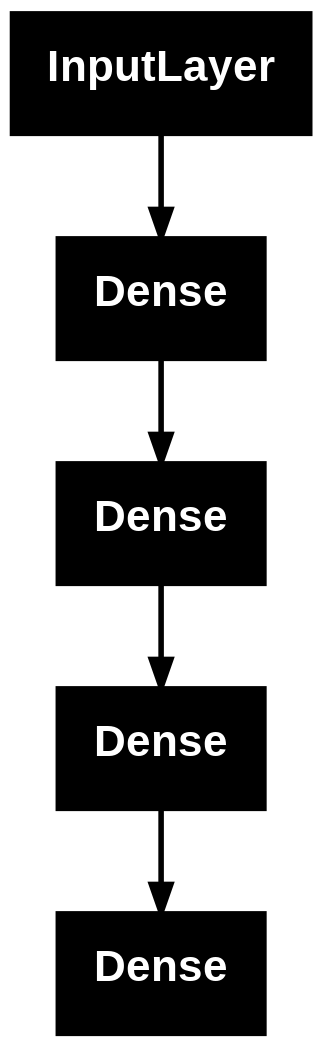

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
input_layer = tf.keras.layers.Input(shape = [784])
dense_layer_1 = tf.keras.layers.Dense(units = 128, activation = tf.nn.sigmoid)(input_layer)
dense_layer_2 = tf.keras.layers.Dense(units = 512, activation = tf.nn.relu)(dense_layer_1)
concat = tf.keras.layers.concatenate([input_layer, dense_layer_2])
output_layer = tf.keras.layers.Dense(units = 10, activation = tf.nn.sigmoid)(concat)

model = tf.keras.Model(inputs = [input_layer], outputs = [output_layer])

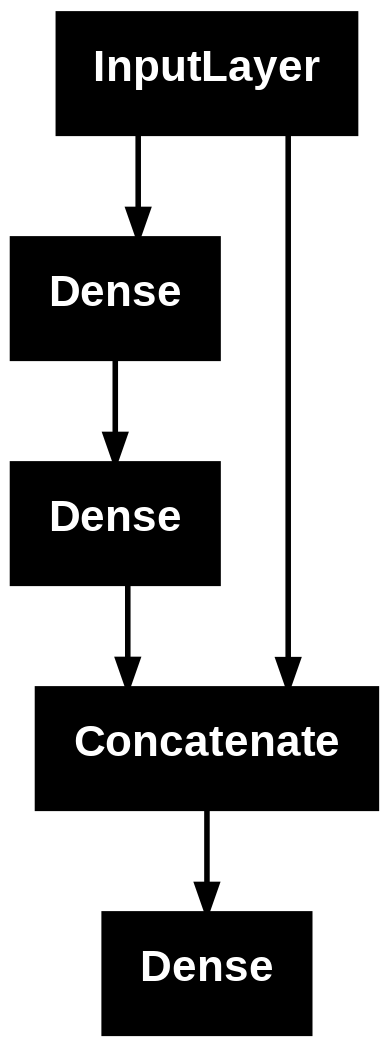

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
"""model.compile(optimizer = tf.optimizers.Adam(),
              loss = tf.losses.CategoricalCrossentropy(),
              metrics = tf.metrics.CategoricalAccuracy()
              )
              """
model.compile("Adam", loss = "categorical_crossentropy", metrics = ["acc"])

In [ ]:
model.fit(x = x_train, y = y_train, batch_size = 32, epochs = 10, validation_split = 0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - acc: 0.8251 - loss: 0.5916 - val_acc: 0.9458 - val_loss: 0.1784
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.9459 - loss: 0.1742 - val_acc: 0.9637 - val_loss: 0.1235
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.9664 - loss: 0.1075 - val_acc: 0.9718 - val_loss: 0.0891
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9760 - loss: 0.0747 - val_acc: 0.9723 - val_loss: 0.0913
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - acc: 0.9806 - loss: 0.0605 - val_acc: 0.9792 - val_loss: 0.0762
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9866 - loss: 0.0430 - val_acc: 0.9732 - val_loss: 0.0949
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.9871 - loss: 0.0372 - val_acc: 0.9823 - val_loss: 0.0696
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - acc: 0.9901 - loss: 0.0297 - val_acc: 0.9802 - val_loss: 0.0772
Epoch 9/10
1688/1688 ━━━━━━━━

<Axes: >

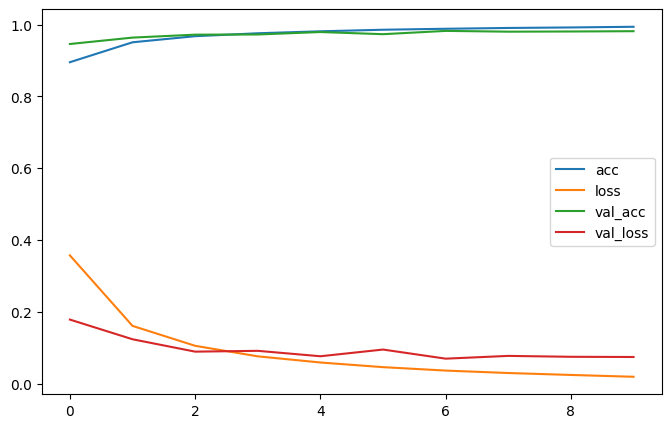

In [ ]:
df = pd.DataFrame(model.history.history)
df.plot(figsize = (8,5))
# Intereption between lines means "overvitting".

In [ ]:
input_layer = tf.keras.layers.Input(shape = [784])
tf.keras.layers.Dropout(0.1)
dense_layer_1 = tf.keras.layers.Dense(units = 128, activation = tf.nn.sigmoid)(input_layer)
tf.keras.layers.Dropout(0.2)
dense_layer_2 = tf.keras.layers.Dense(units = 512, activation = tf.nn.relu)(dense_layer_1)
tf.keras.layers.Dropout(0.3)
dense_layer_3 = tf.keras.layers.Dense(units = 256, activation = tf.nn.relu)(dense_layer_2)
tf.keras.layers.Dropout(0.4)
output_layer = tf.keras.layers.Dense(units = 10, activation = tf.nn.sigmoid)(dense_layer_3)
# It reduce the complixety of the model.
model = tf.keras.Model(inputs = [input_layer], outputs = [output_layer])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,426 (1.15 MB)

 Trainable params: 300,426 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

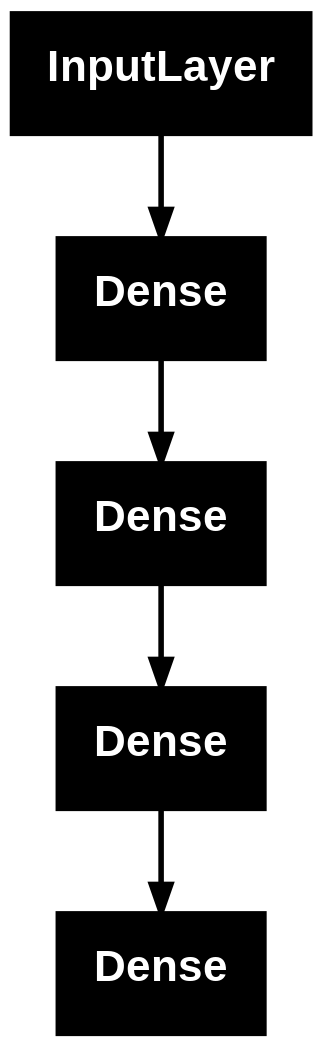

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
"""model.compile(optimizer = tf.optimizers.Adam(),
              loss = tf.losses.CategoricalCrossentropy(),
              metrics = tf.metrics.CategoricalAccuracy()
              )
              """
model.compile("Adam", loss = "categorical_crossentropy", metrics = ["acc"])

In [ ]:
model.fit(x = x_train, y = y_train, batch_size = 32, epochs = 10, validation_split = 0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - acc: 0.8027 - loss: 0.6013 - val_acc: 0.9488 - val_loss: 0.1767
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - acc: 0.9495 - loss: 0.1646 - val_acc: 0.9650 - val_loss: 0.1144
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - acc: 0.9660 - loss: 0.1067 - val_acc: 0.9713 - val_loss: 0.0921
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - acc: 0.9762 - loss: 0.0773 - val_acc: 0.9708 - val_loss: 0.0987
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.9807 - loss: 0.0590 - val_acc: 0.9752 - val_loss: 0.0870
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - acc: 0.9844 - loss: 0.0477 - val_acc: 0.9797 - val_loss: 0.0799
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.9866 - loss: 0.0399 - val_acc: 0.9813 - val_loss: 0.0732
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - acc: 0.9907 - loss: 0.0284 - val_acc: 0.9788 - val_loss: 0.0874
Epoch 9/10
1688/1688 ━━━━━━

In [ ]:
# increasing model layers.
def wide_block(x, units = 512, dropout_rate = 0.2):
  dense_layer_1 = tf.keras.layers.Dense(units = units, activation = tf.nn.sigmoid)(x)
  tf.keras.layers.Dropout(dropout_rate)
  dense_layer_2 = tf.keras.layers.Dense(units = units, activation = tf.nn.sigmoid)(dense_layer_1)
  tf.keras.layers.Dropout(dropout_rate)
  dense_layer_3 = tf.keras.layers.Dense(units = units, activation = tf.nn.sigmoid)(dense_layer_2)
  concat = tf.keras.layers.concatenate([input_layer, dense_layer_3])
  return concat

In [ ]:
input_layer = tf.keras.layers.Input(shape = [784])
block1 = wide_block(input_layer)
block2 = wide_block(block1)
output_layer = tf.keras.layers.Dense(units = 10, activation = tf.nn.sigmoid)(block2)
model = tf.keras.Model(inputs = [input_layer], outputs = [output_layer])
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 512)       │    401,920 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 512)       │    262,656 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 512)       │    262,656 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1296)      │          0 │ input_layer_5[0]… │
│ (Concatenate)       │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 512)       │    664,064 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 512)       │    262,656 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 512)       │    262,656 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 1296)      │          0 │ input_layer_5[0]… │
│ (Concatenate)       │                   │            │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 10)        │     12,970 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,129,578 (8.12 MB)

 Trainable params: 2,129,578 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

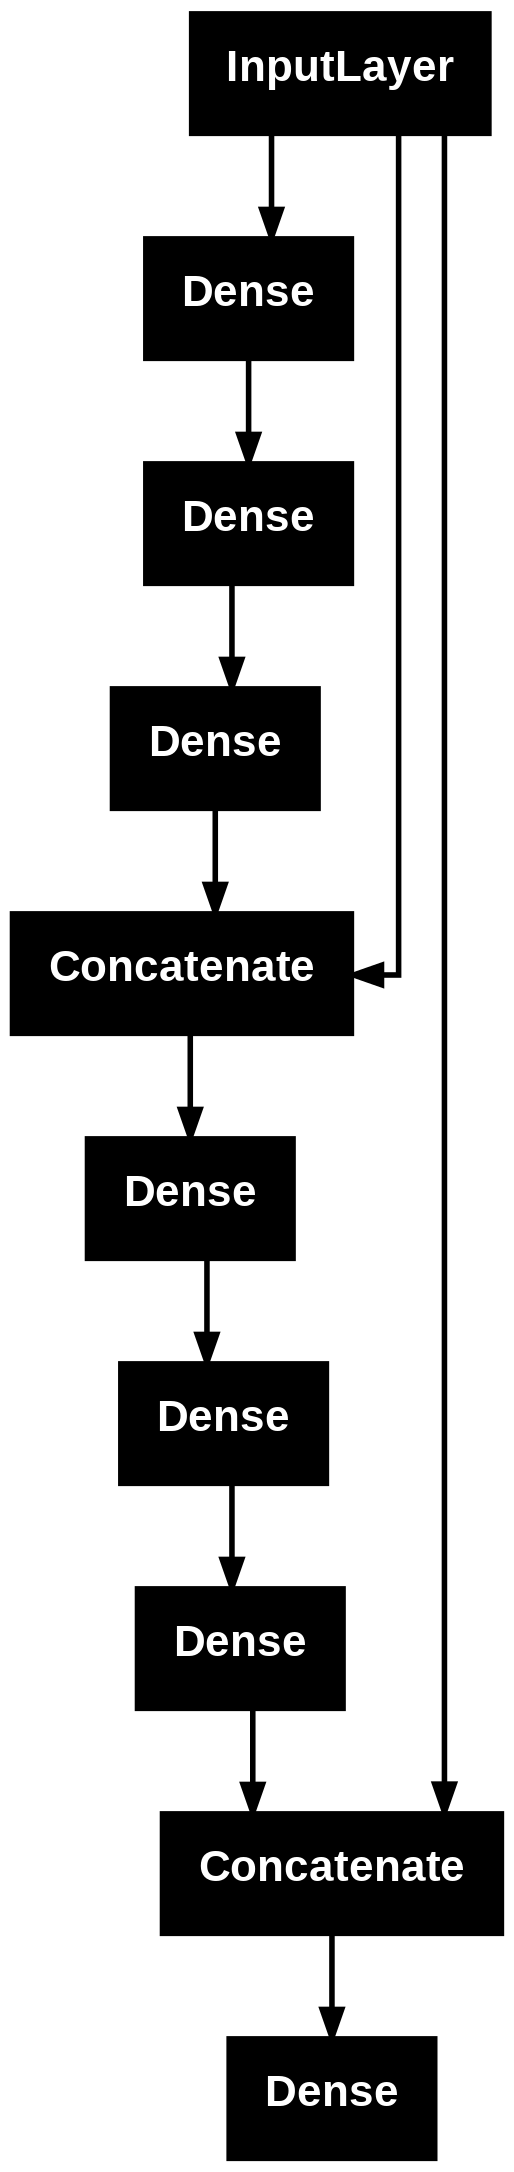

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
"""model.compile(optimizer = tf.optimizers.Adam(),
              loss = tf.losses.CategoricalCrossentropy(),
              metrics = tf.metrics.CategoricalAccuracy()
              )
              """
model.compile("Adam", loss = "categorical_crossentropy", metrics = ["acc"])

In [ ]:
model.fit(x = x_train, y = y_train, batch_size = 32, epochs = 10, validation_split = 0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 37ms/step - acc: 0.8141 - loss: 0.6177 - val_acc: 0.9475 - val_loss: 0.1711
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - acc: 0.9454 - loss: 0.1772 - val_acc: 0.9688 - val_loss: 0.1073
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - acc: 0.9666 - loss: 0.1051 - val_acc: 0.9737 - val_loss: 0.0917
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 50ms/step - acc: 0.9774 - loss: 0.0709 - val_acc: 0.9770 - val_loss: 0.0840
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - acc: 0.9827 - loss: 0.0541 - val_acc: 0.9803 - val_loss: 0.0735
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 89s 44ms/step - acc: 0.9859 - loss: 0.0436 - val_acc: 0.9807 - val_loss: 0.0737
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 69s 36ms/step - acc: 0.9896 - loss: 0.0327 - val_acc: 0.9807 - val_loss: 0.0856
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 92s 42ms/step - acc: 0.9918 - loss: 0.0244 - val_acc: 0.9835 - val_loss: 0.0673
Epoch 9/10
1688/1688 ━━━

# Subclassing API

In [ ]:
class WideDeepModel(tf.keras.Model):
  def __init__(self, input_shape, units= 30, act = 'relu', **kwargs):
    super (WideDeepModel, self).__init__(**kwargs)

    self.input_layer = tf.keras.layers.Input(input_shape)
    self.dense_layer_1 = tf.keras.layers.Dense(units = units, activation = act)
    self.dropout1 = tf.keras.layers.Dropout(0.2)
    self.dense_layer_2 = tf.keras.layers.Dense(units = units, activation = act)
    self.dropout2 = tf.keras.layers.Dropout(0.2)
    self.output_layer = tf.keras.layers.Dense(units = 10, activation = "softmax")

  def graph_build(self):
    x = self.input_layer
    return tf.keras.Model(inputs = [x], outputs = self.call(x))

  def call(self, inputs):
    x = self.dense_layer_1(inputs)
    x = self.dropout1(x)
    x = self.dense_layer_2(x)
    x = self.dropout2(x)
    concat = tf.keras.layers.concatenate([x, inputs])
    output = self.output_layer(concat)
    return output

In [ ]:
model = WideDeepModel(input_shape = [784])
model.build(input_shape = (None, 784))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'wide_deep_model_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "wide_deep_model_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

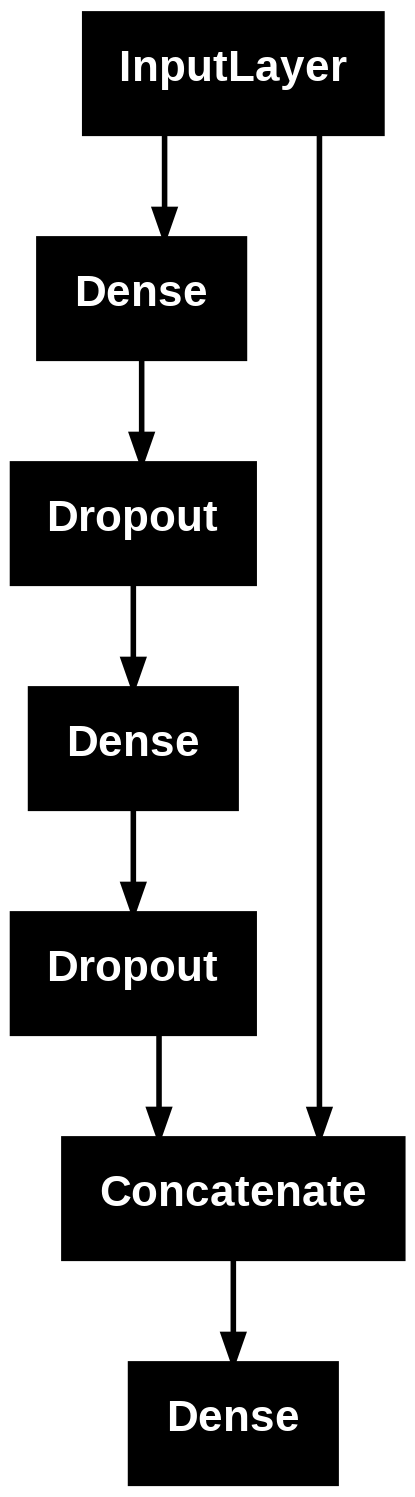

In [ ]:
tf.keras.utils.plot_model(model.graph_build())

In [ ]:
model.compile("Adam", loss = "categorical_crossentropy", metrics = ["acc"])
model.fit(x = x_train, y = y_train, batch_size = 32, epochs = 10, validation_split = 0.1)
# Note: When we rerun the code, the number of epochs increase, not start from 1 again. It complete from the last value.

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8259 - loss: 0.6091 - val_acc: 0.9487 - val_loss: 0.1874
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9445 - loss: 0.1967 - val_acc: 0.9622 - val_loss: 0.1337
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.9575 - loss: 0.1405 - val_acc: 0.9655 - val_loss: 0.1149
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.9659 - loss: 0.1129 - val_acc: 0.9678 - val_loss: 0.1125
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9702 - loss: 0.0940 - val_acc: 0.9672 - val_loss: 0.1141
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9750 - loss: 0.0824 - val_acc: 0.9688 - val_loss: 0.1081
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9790 - loss: 0.0689 - val_acc: 0.9690 - val_loss: 0.1110
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - acc: 0.9797 - loss: 0.0659 - val_acc: 0.9723 - val_loss: 0.0991
Epoch 9/10
1688/1688 ━━━━━━━━━━━━━━━━━━

<Axes: >

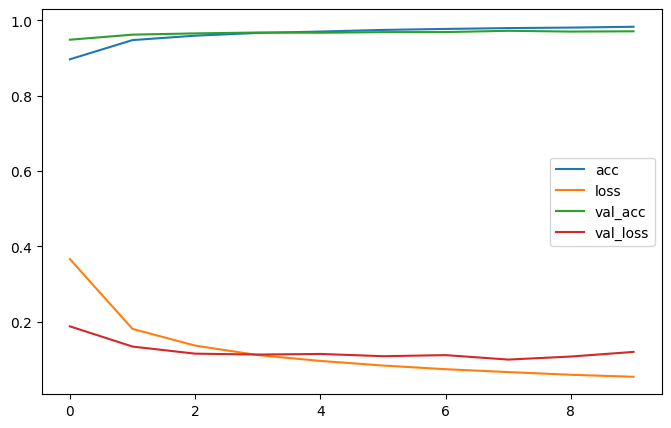

In [ ]:
df = pd.DataFrame(model.history.history)
df.plot(figsize = (8,5))